# Week 3 — Session 9
## Covariance, Correlation & Simple Linear Regression

### Goals
- Understand Covariance
- Measure linear relationships with Correlation
- Visualize relationships with Scatter Plots
- Build a Simple Linear Regression model
- Interpret Slope and Intercept
- Calculate Predictions and Residuals
- Interpret R-squared correctly
- Apply relationship analysis to Tehran urban indicators

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Example Urban Dataset

Each row represents one hypothetical urban observation.

Variables:

- distance_to_metro: distance to metro in meters
- travel_time: travel time in minutes

In [2]:
data = pd.DataFrame({
    "distance_to_metro": [200, 300, 500, 700, 900, 1100],
    "travel_time": [19, 21, 24, 28, 31, 35]
})

data

,distance_to_metro,travel_time
0,200,19
1,300,21
2,500,24
3,700,28
4,900,31
5,1100,35


# Covariance

Covariance shows whether two variables tend to move in the same direction or in opposite directions.

Positive Covariance:
X increases and Y also tends to increase.

Negative Covariance:
X increases while Y tends to decrease.

In [3]:
covariance = data["distance_to_metro"].cov(
    data["travel_time"]
)

print("Covariance:", covariance)

Covariance: 2133.3333333333335


## Interpretation

The covariance is positive.

This means that greater distance to metro tends to occur together with greater travel time.

The magnitude of covariance is unit-dependent, so it is not ideal for comparing relationship strength across variables.

# Pearson Correlation

Correlation standardizes the relationship between two variables.

Its value is always between:

-1 and +1

In [4]:
correlation = data["distance_to_metro"].corr(
    data["travel_time"]
)

print("Correlation:", correlation)

Correlation: 0.9991953082738326


## Interpretation

A value close to +1 indicates a strong positive linear relationship.

A value close to -1 indicates a strong negative linear relationship.

A value close to 0 indicates a weak linear relationship.

Important:

Correlation does not prove causation.

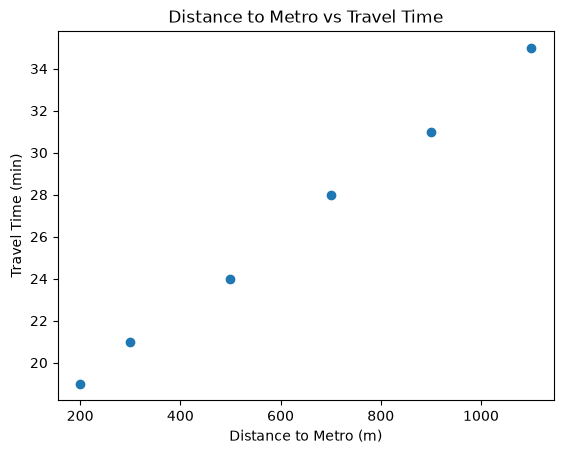

In [5]:
plt.scatter(
    data["distance_to_metro"],
    data["travel_time"]
)

plt.xlabel("Distance to Metro (m)")
plt.ylabel("Travel Time (min)")
plt.title("Distance to Metro vs Travel Time")

plt.show()

## Why Visualization Matters

A correlation value alone is not enough.

The Scatter Plot helps us detect:

- Linear or nonlinear patterns
- Outliers
- Clusters
- Suspicious observations

In [6]:
green_space = np.array([5, 10, 15, 20, 25])
temperature = np.array([39, 37, 34, 32, 29])

r_green_temp = np.corrcoef(
    green_space,
    temperature
)[0, 1]

print("Correlation:", r_green_temp)

Correlation: -0.9976086055845277


## Interpretation

Green Space increases while Surface Temperature decreases.

Therefore the correlation is negative.

However, this does not prove that Green Space alone causes the temperature reduction.

Other variables may also influence temperature.

# Simple Linear Regression

We now model Travel Time as a function of Distance to Metro.

Model:

Y = Intercept + Slope × X

In [7]:
x = data["distance_to_metro"]
y = data["travel_time"]

result = stats.linregress(x, y)

print("Slope:", result.slope)
print("Intercept:", result.intercept)
print("Correlation:", result.rvalue)
print("p-value:", result.pvalue)
print("Slope Standard Error:", result.stderr)

Slope: 0.017534246575342465
Intercept: 15.520547945205479
Correlation: 0.9991953082738326
p-value: 9.710326307198263e-07
Slope Standard Error: 0.00035192418023739206


In [8]:
effect_per_100m = result.slope * 100

print(
    "Estimated change in Travel Time per 100 m:",
    effect_per_100m
)

Estimated change in Travel Time per 100 m: 1.7534246575342465


## Interpretation

The Slope shows how much Travel Time is expected to change when Distance to Metro increases.

Using 100 meters rather than 1 meter often makes the interpretation easier.

Use wording such as:

"Every additional 100 meters of distance to metro is associated with an estimated increase of X minutes in travel time."

Do not automatically interpret this as causation.

In [9]:
data["predicted_travel_time"] = (
    result.intercept
    + result.slope
    * data["distance_to_metro"]
)

data

,distance_to_metro,travel_time,predicted_travel_time
0,200,19,19.027397
1,300,21,20.780822
2,500,24,24.287671
3,700,28,27.794521
4,900,31,31.301370
5,1100,35,34.808219


In [10]:
new_distance = 600

predicted_time = (
    result.intercept
    + result.slope * new_distance
)

print(
    "Predicted Travel Time:",
    predicted_time
)

Predicted Travel Time: 26.041095890410958


## Prediction Interpretation

The model estimates the expected Travel Time for a given Distance to Metro.

A prediction is not guaranteed to equal the actual observed value.

In [11]:
data["residual"] = (
    data["travel_time"]
    - data["predicted_travel_time"]
)

data

,distance_to_metro,travel_time,predicted_travel_time,residual
0,200,19,19.027397,-0.027397
1,300,21,20.780822,0.219178
2,500,24,24.287671,-0.287671
3,700,28,27.794521,0.205479
4,900,31,31.301370,-0.301370
5,1100,35,34.808219,0.191781


# Residual

Residual = Actual - Predicted

Positive Residual:
The model predicted a value lower than the actual observation.

Negative Residual:
The model predicted a value higher than the actual observation.

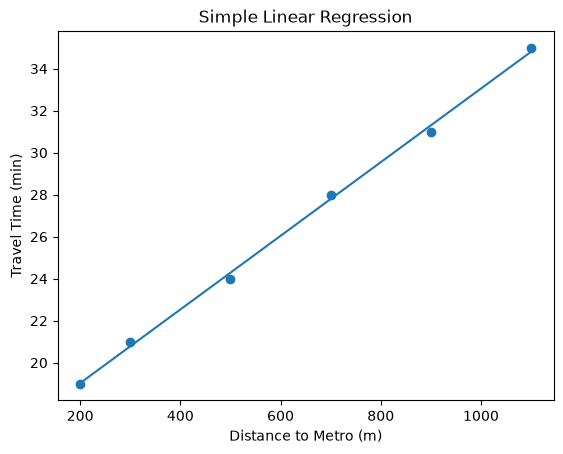

In [12]:
plt.scatter(
    data["distance_to_metro"],
    data["travel_time"]
)

plt.plot(
    data["distance_to_metro"],
    data["predicted_travel_time"]
)

plt.xlabel("Distance to Metro (m)")
plt.ylabel("Travel Time (min)")
plt.title("Simple Linear Regression")

plt.show()

In [13]:
r_squared = result.rvalue ** 2

print("R-squared:", r_squared)

R-squared: 0.9983912640764394


# R-squared

R-squared describes how much of the observed variation in Y is explained by the linear model.

Example:

R² = 0.67

means approximately 67% of the observed variation in Y is explained by the model.

R² is NOT:

- Prediction accuracy
- Residual error
- Percentage of correct predictions

In [14]:
comparison = data[
    [
        "distance_to_metro",
        "travel_time",
        "predicted_travel_time",
        "residual"
    ]
]

comparison

,distance_to_metro,travel_time,predicted_travel_time,residual
0,200,19,19.027397,-0.027397
1,300,21,20.780822,0.219178
2,500,24,24.287671,-0.287671
3,700,28,27.794521,0.205479
4,900,31,31.301370,-0.301370
5,1100,35,34.808219,0.191781


# Tehran Data-to-Design Intelligence

Possible relationships to study:

- Distance to Metro ↔ Travel Time
- Green Space ↔ Surface Temperature
- Intersection Density ↔ Pedestrian Activity
- Population Density ↔ Commercial Activity
- Distance to Park ↔ Park Usage

# Urban Intelligence Workflow

For relationship analysis:

1. Visualize
2. Quantify
3. Model
4. Interpret

Do not move directly from Correlation to a design decision.

## Example Interpretation

Suppose:

Correlation = 0.78

Regression:

Travel Time = 14 + 0.018 × Distance to Metro

R² = 0.61

Interpretation:

There is a moderately strong positive linear relationship between Distance to Metro and Travel Time.

The model estimates that every additional 100 meters of distance is associated with approximately 1.8 additional minutes of Travel Time.

Approximately 61% of the observed variation in Travel Time is explained by this simple linear model.

However, the result does not prove causation. Other variables such as street connectivity, traffic, transport mode, and urban location may also influence Travel Time.

# Error Log

## E014 — R-squared vs Error

Incorrect:

"R² is the amount of error in the fitted line."

Correct:

R² describes the proportion of observed variation in Y explained by the model.

Residuals describe observation-level prediction errors.

---

## E001 Reminder — Correlation vs Causation

A strong correlation or regression relationship does not prove that X causes Y.

# Independent Exercise

Suppose the model is:

Park Usage = 120 - 0.08 × Distance to Park

and:

R² = 0.67

For a site located 500 meters from the park:

1. Calculate predicted Park Usage.
2. Interpret the Slope.
3. Interpret R².
4. If Actual Park Usage is 90, calculate the Residual.
5. Explain why the model does not prove that distance causes park usage.

# Session Summary

Covariance:
Shows whether two variables tend to move together or in opposite directions.

Correlation:
Measures the strength and direction of a linear relationship.

Regression:
Models how Y changes with X and enables prediction.

Slope:
Expected change in Y for a one-unit change in X.

Prediction:
The value estimated by the model.

Residual:
Actual - Predicted.

R-squared:
The proportion of variation in Y explained by the model.

Key Rule:

Correlation and Regression do not automatically imply causation.